In [1]:
!pip install -q pyarrow fastparquet

**Берем только Москву и область, выкидываем текст**

In [2]:
import os
import pandas as pd

if not os.path.isfile("../data/yandex_geo_msk.csv"):
    df = pd.read_parquet("hf://datasets/d0rj/geo-reviews-dataset-2023/data/train-00000-of-00001-49261e4e5a35a5a0.parquet")
    mask = (df['address'].str.contains('Москва|Московская область', na=False, case=False))
    df = df[mask].drop("text", axis=1)
    df.to_csv("../data/yandex_geo.csv", index=False)
else:
    df = pd.read_csv("../data/yandex_geo_msk.csv")

df

,address,name_ru,rating,rubrics
0,"Московская область, Электросталь, проспект Лен...",Продукты Ермолино,5,Магазин продуктов;Продукты глубокой заморозки;...
1,"Москва, 4-й Кожевнический переулок, 4",Jinju,5,Кафе;Кофейня
2,"Москва, 4-й Кожевнический переулок, 4",Jinju,4,Кафе;Кофейня
3,"Москва, улица Малая Дмитровка, 15",Healingbowl,5,Магазин подарков и сувениров;Музыкальный магазин
4,"Московская область, Наро-Фоминск, улица Калини...",Автомойка Чистякоff,1,Автомойка
...,...,...,...,...
154753,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,5,Железнодорожная станция
154754,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,5,Железнодорожная станция
154755,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,5,Железнодорожная станция
154756,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,4,Железнодорожная станция


**Видим много дубликатов по столбцам `address` и `name_ru`, однако `rating` может отличаться. Считаем средний рейтинг.**

In [3]:
df = df.groupby(['address', 'name_ru']).agg({
    'rating': 'mean',
    'rubrics': 'first'
}).reset_index()
df.rename(columns={'rating': 'avg_rating'}, inplace=True)
df = df.sort_values(by="address")
df

,address,name_ru,avg_rating,rubrics
0,"г. Москва, пр-кт Волгоградский, д. 46 Б",Стратегия Оценки,5.0,Оценочная компания;Экспертиза;Строительная экс...
1,",Москва, Западный административный округ, райо...",One and Double,1.0,Кофейня
2,"Адрес: Московская область, Люберецкий район, Б...",Газмагистраль,5.0,"АГНС, АГЗС, АГНКС"
9,Москва,Экспериментальный квартал,5.0,Достопримечательность
7,Москва,ОкнаДел,5.0,Окна;Изготовление витражей;Реставрационная мас...
...,...,...,...,...
78780,"город Москва, Молодогвардейская улица, 61с16",Цветы в Деталях,5.0,Курсы и мастер-классы
78781,"город Москва, улица Исаковского, 20",Колфи,4.0,Магазин продуктов
78782,"городской округ Брянск, посёлок Белые Берега, ...",Автозавод Бергер,4.0,Автомобильные прицепы
78783,"городской округ Луховицы Московская область, Р...",Пикниковая зона,5.0,Место для пикника


**Посмотрим на распределение `rating`**

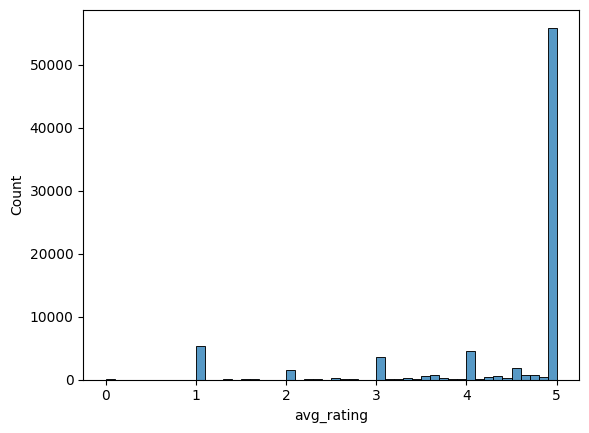

In [4]:
import seaborn as sns

_ = sns.histplot(df, x="avg_rating", bins=50)

**Видим, что в датасете недостаточно данных об отзывах. Что имеем, то имеем.**

In [5]:
df["address"].sample(10)

53199    Московская область, Дмитровский городской окру...
33418              Москва, Южнопортовая улица, 15, стр. 4А
7403                 Москва, Верейская улица, 29, стр. 106
17912            Москва, Малая Юшуньская улица, 1, корп. 2
70162    Московская область, Серпухов, Борисовское шосс...
75133    Московская область, городской округ Красногорс...
39022                        Москва, улица 1905 года, 10с1
48261              Москва, улица Сущёвский Вал, 5, стр. 1А
43645                      Москва, улица Красных Зорь, 59Б
33129           Москва, Электрозаводская улица, 23, стр. 8
Name: address, dtype: object

In [109]:
geocoded = pd.concat([
    pd.read_csv('../data/geocoded_0_57500.csv'),
    pd.read_csv('../data/geocoded_57500_plus.csv'),
], axis=0)
geocoded.to_csv('../data/moscow_geocoded.csv', index=False)

In [110]:
pd.set_option('display.max_colwidth', 100)

df = pd.read_csv('../data/moscow_geocoded.csv')
df = df[df[["lat", "lon"]].isna().any(axis=1)]
df["address"]

0                                                        г. Москва, пр-кт Волгоградский, д. 46 Б
1        ,Москва, Западный административный округ, район Фили-Давыдково Метро Славянский бульвар
2                          Адрес: Московская область, Люберецкий район, Быковское шоссе, дом 55А
10                                                  Москва, 1-й Автозаводский проезд, 4, корп. 1
11                                                  Москва, 1-й Автозаводский проезд, 4, корп. 1
                                                  ...                                           
78778                                                   г. Москва, ул. Рогожский Вал, 11, стр. 1
78779                                         г. Москва, ул. Спартаковская площадь дом 10 стр.12
78780                                               город Москва, Молодогвардейская улица, 61с16
78781                                                        город Москва, улица Исаковского, 20
78782    городской округ Брянс

In [111]:
df["address"].sample(10)

76125                   Московская область, городской округ Люберцы, посёлок Чкалово, Советская улица, 148/2
46642                                                                   Москва, улица Пивченкова, 1, корп. 3
38952                                                                 Москва, ул. Мироновская, 46 и 46, к. 1
64537       Московская область, Одинцовский городской округ, деревня Малые Вязёмы, Северная улица, 1, стр. 1
14964                                                                 Москва, Лебедянская улица, 19, корп. 1
21027                                                             Москва, Новодмитровская улица, 2, корп. 1А
52314    Московская область, Волоколамский городской округ, садоводческое некоммерческое товарищество Зел...
35576                                     Москва, поселение Московский, Киевское шоссе, 22-й километр, 4с2кВ
67568                                  Московская область, Раменский городской округ, дачный посёлок Кратово
4737               

In [112]:
!pip install -q geopy

In [113]:
from geopy.geocoders import Nominatim, Photon
from geopy.extra.rate_limiter import RateLimiter


geolocator = Photon(user_agent="my_geo_research_v1.0", timeout=10)
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)  # лимит 1 запрос/сек

In [114]:
geocode("Московская область, городской округ Люберцы, рабочий посёлок Октябрьский, улица Ленина, 22")

Location(22, улица Ленина, 140060, улица Ленина, Октябрьский, Московская область, Россия, (55.6092157, 37.975038121836164, 0.0))

In [115]:
import os
import time
import numpy as np
from tqdm import tqdm
from functools import lru_cache


@lru_cache(maxsize=8 * 3600)
def geocode_cached(address):
    try:
        location = geocode(address)
        return location
    except Exception as e:
        print(f"Ошибка при геокодировании {address}: {e}")
        return None


def batch_geocode_df(df, batch_size, checkpoints_dir):
    result_df = df.copy()
    result_df[['lat', 'lon']] = np.nan
    result_df['geocode_status'] = ''

    os.makedirs(checkpoints_dir, exist_ok=True)
    
    def save_checkpoint(current_index):
        checkpoint_file = f'{checkpoints_dir}/chkt.csv'
        result_df.to_csv(checkpoint_file, index=False, encoding='utf-8')
        print(f"\nСохранен чекпоинт: {checkpoint_file}")
    
    total_addresses = len(result_df)
    print(f"Начинаем геокодирование {total_addresses} адресов...")
    print(f"Примерное время: ~{total_addresses / 3600:.1f} часов (1 запрос/сек)")
    for idx, row in tqdm(result_df.iterrows(), total=total_addresses, desc="Геокодирование"):
        try:
            location = geocode_cached(row["address"])
            if location:
                result_df.at[idx, 'lat'] = location.latitude
                result_df.at[idx, 'lon'] = location.longitude
                result_df.at[idx, 'geocode_status'] = 'success'
            else:
                result_df.at[idx, 'geocode_status'] = 'not_found'
                
        except Exception as e:
            result_df.at[idx, 'geocode_status'] = f'error: {str(e)[:50]}'
        
        # Сохраняем чекпоинт каждые batch_size записей
        if idx > 0 and idx % batch_size == 0:
            save_checkpoint(idx)
            # Также сохраняем статистику успешных запросов
            success_rate = (result_df['geocode_status'] == 'success').sum() / (idx + 1) * 100
            print(f"Прогресс: {idx+1}/{total_addresses}, Успешно: {success_rate:.1f}%")
    
    success_count = (result_df['geocode_status'] == 'success').sum()
    not_found_count = (result_df['geocode_status'] == 'not_found').sum()
    error_count = len(result_df) - success_count - not_found_count
    
    print("\n" + "="*50)
    print("ГЕОКОДИРОВАНИЕ ЗАВЕРШЕНО")
    print("="*50)
    print(f"Всего адресов: {len(result_df)}")
    print(f"Успешно геокодировано: {success_count} ({success_count/len(result_df)*100:.1f}%)")
    print(f"Не найдено: {not_found_count} ({not_found_count/len(result_df)*100:.1f}%)")
    print(f"Ошибок: {error_count} ({error_count/len(result_df)*100:.1f}%)")
    
    return result_df

In [ ]:
df_err = df

result_err = batch_geocode_df(df_err, batch_size=3600, checkpoints_dir="../data/geocoding_err")
result_err.to_csv('../data/geocoded_err.csv', index=False, encoding='utf-8')

Начинаем геокодирование 29060 адресов...
Примерное время: ~8.1 часов (1 запрос/сек)


Геокодирование:   5%|██▋                                                        | 1332/29060 [13:05<6:53:26,  1.12it/s]


Сохранен чекпоинт: ../data/geocoding_err/chkt.csv
Прогресс: 3601/29060, Успешно: 36.9%


Геокодирование:  14%|████████▍                                                  | 4145/29060 [40:29<1:53:38,  3.65it/s]


Сохранен чекпоинт: ../data/geocoding_err/chkt.csv
Прогресс: 10801/29060, Успешно: 38.1%


...

Геокодирование:  47%|██████████████████████████▏                             | 13596/29060 [2:10:23<4:13:43,  1.02it/s]


Сохранен чекпоинт: ../data/geocoding_err/chkt.csv
Прогресс: 36001/29060, Успешно: 37.1%


Геокодирование:  53%|█████████████████████████████▊                          | 15442/29060 [2:28:10<1:47:23,  2.11it/s]


Сохранен чекпоинт: ../data/geocoding_err/chkt.csv
Прогресс: 39601/29060, Успешно: 38.1%


Геокодирование:  54%|██████████████████████████████▏                         | 15676/29060 [2:30:34<1:33:29,  2.39it/s]

In [26]:
import requests

# Проверьте доступность OSM
try:
    response = requests.get("https://nominatim.openstreetmap.org/", timeout=5)
    print(f"Статус OSM: {response.status_code}")
    print(f"Заголовки: {response.headers.get('X-Error-Message', 'Нет ошибки')}")
except Exception as e:
    print(f"Ошибка подключения: {e}")

Статус OSM: 200
Заголовки: Нет ошибки
